# Clase 3 — Práctica Individual resuelta
## Segmentación y series de tiempo
### Maestría en Fintech · ITBA · 2026

---

Una forma de resolver los 10 ejercicios de `Clase_3_Practica_Individual.ipynb`, con la **lectura de negocio** de cada uno.

> **Hay más de un camino correcto.** Si llegaste al mismo resultado por otra vía, está bien. Y si todavía no la intentaste, hacelo primero: mirar la solución antes es como leer el final de la película.

Ejecutá **`Entorno de ejecución → Ejecutar todo`**: los datos se descargan solos del repo del curso.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

DATOS = 'https://raw.githubusercontent.com/camilojaure/itba-pad/main/datasets/'
df = pd.read_csv(DATOS + 'transacciones.csv')

df['fecha'] = pd.to_datetime(df['fecha'])
df['mes'] = df['fecha'].dt.month
df['trimestre'] = df['fecha'].dt.quarter
df['dia_semana'] = df['fecha'].dt.day_name()

print(f'{len(df):,} transacciones — de {df.fecha.min():%d/%m/%Y} a {df.fecha.max():%d/%m/%Y}')

28,956 transacciones — de 01/01/2024 a 31/12/2024


### Ejercicio 1 · Débito vs crédito

In [2]:
df.groupby('tipo').agg(
    transacciones=('transaccion_id', 'count'),
    ticket_promedio=('monto_ars', 'mean'),
    ticket_mediano=('monto_ars', 'median'),
).round(0)

,transacciones,ticket_promedio,ticket_mediano
tipo,,,
crédito,10630,78902.0,45524.0
débito,18326,51029.0,30469.0


**Lectura esperada:** el crédito tiene un ticket ~55% mayor ($78,9k vs $51,0k) con muchas menos transacciones.
Lo grande se financia; lo cotidiano se paga con débito.

### Ejercicio 2 · Día de la semana

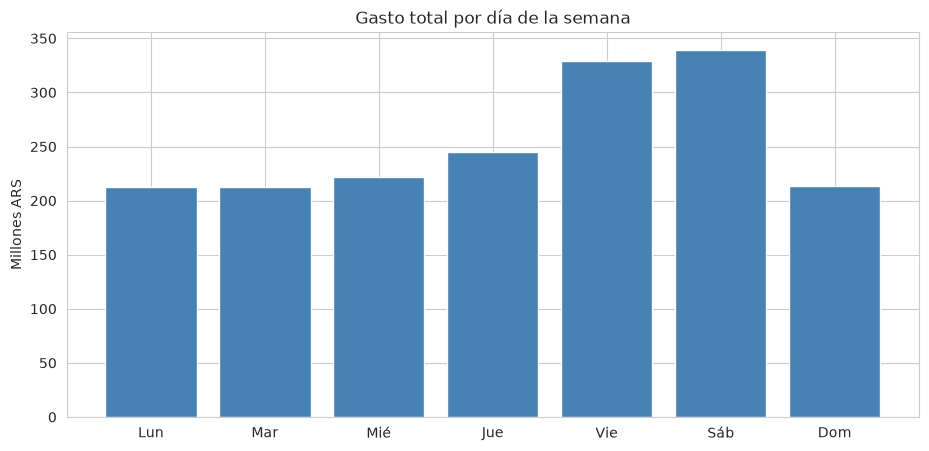

dia_semana
Monday       12.0
Tuesday      12.0
Wednesday    12.5
Thursday     13.8
Friday       18.6
Saturday     19.1
Sunday       12.0
Name: monto_ars, dtype: float64


In [3]:
orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
etiquetas = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

por_dia = df.groupby('dia_semana')['monto_ars'].sum().reindex(orden) / 1e6

plt.bar(etiquetas, por_dia.values, color='steelblue')
plt.title('Gasto total por día de la semana')
plt.ylabel('Millones ARS')
plt.show()

print((por_dia / por_dia.sum() * 100).round(1))

**Lectura esperada:** viernes y sábado concentran ~38% del gasto; los otros cinco días rondan 12–14% cada uno.
Promociones: jueves/viernes para capturar el fin de semana. Capacidad: reforzar viernes y sábado.

### Ejercicio 3 · Ticket promedio por categoría y trimestre

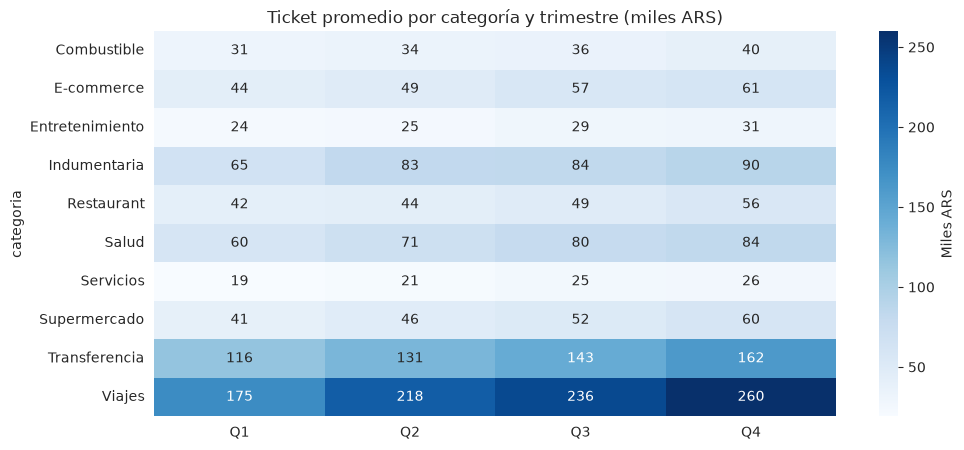

In [4]:
pivot = df.pivot_table(values='monto_ars', index='categoria', columns='trimestre', aggfunc='mean')
pivot.columns = [f'Q{c}' for c in pivot.columns]

sns.heatmap(pivot / 1000, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Miles ARS'})
plt.title('Ticket promedio por categoría y trimestre (miles ARS)')
plt.show()

**Lectura esperada:** el ticket sube en todas las categorías de Q1 a Q4. Que suba *parejo en todas* es la firma de la inflación,
no de un cambio de comportamiento. La respuesta buena distingue "la gente compra más caro" de "las cosas cuestan más".

### Ejercicio 4 · Rechazos por mes

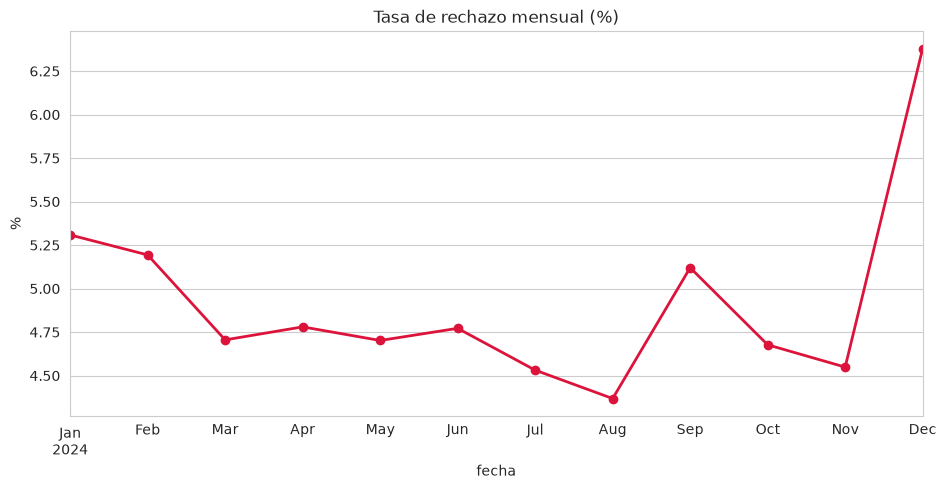

,total,rechazadas,tasa_rechazo
fecha,,,
2024-01-31,2204,117,5.3
2024-02-29,2041,106,5.2
2024-03-31,2359,111,4.7
2024-04-30,2343,112,4.8
2024-05-31,2382,112,4.7
2024-06-30,2410,115,4.8
2024-07-31,2604,118,4.5
2024-08-31,2335,102,4.4
2024-09-30,2246,115,5.1


In [5]:
rechazos = df.set_index('fecha').resample('ME').agg(
    total=('aprobada', 'count'),
    rechazadas=('aprobada', lambda s: (s == 0).sum()),
    tasa_rechazo=('aprobada', lambda s: 1 - s.mean()),
)

(rechazos['tasa_rechazo'] * 100).plot(marker='o', color='crimson', linewidth=2)
plt.title('Tasa de rechazo mensual (%)')
plt.ylabel('%')
plt.show()

rechazos.assign(tasa_rechazo=(rechazos['tasa_rechazo'] * 100).round(1))

**Lectura esperada:** todos los meses entre 4,4% y 5,3%, y **diciembre salta a 6,4%** (197 rechazos vs ~110 de un mes normal).
En cantidad absoluta el salto se confunde con que diciembre tiene más volumen; la tasa muestra que además rechaza *proporcionalmente* más.
Pregunta a operaciones: ¿reglas antifraude más estrictas en fiestas? ¿límites alcanzados por el gasto de fin de año? Cada rechazo indebido es una venta perdida en el mejor mes.

### Ejercicio 5 · Crecimiento Q1 → Q4

In [6]:
monto_q = df.pivot_table(values='monto_ars', index='categoria', columns='trimestre', aggfunc='sum')
cant_q = df.pivot_table(values='transaccion_id', index='categoria', columns='trimestre', aggfunc='count')

crec = pd.DataFrame({
    'crec_monto_%': (monto_q[4] / monto_q[1] - 1) * 100,
    'crec_cantidad_%': (cant_q[4] / cant_q[1] - 1) * 100,
}).sort_values('crec_monto_%', ascending=False).round(1)

crec

,crec_monto_%,crec_cantidad_%
categoria,,
E-commerce,216.0,128.3
Indumentaria,71.2,23.4
Viajes,65.1,11.2
Salud,60.3,14.5
Servicios,57.9,15.6
Supermercado,54.4,4.7
Combustible,54.2,21.0
Restaurant,50.3,11.9
Entretenimiento,49.3,14.8


**Lectura esperada:** **E-commerce** es la única que crece de verdad: +216% en monto y +128% en cantidad.
El resto sube entre +46% y +71% en monto pero solo +5% a +23% en cantidad: casi todo es precio.
Supermercado y Transferencia prácticamente no crecen en cantidad (~+5%).

### Ejercicio 6 · Media móvil de 6 meses

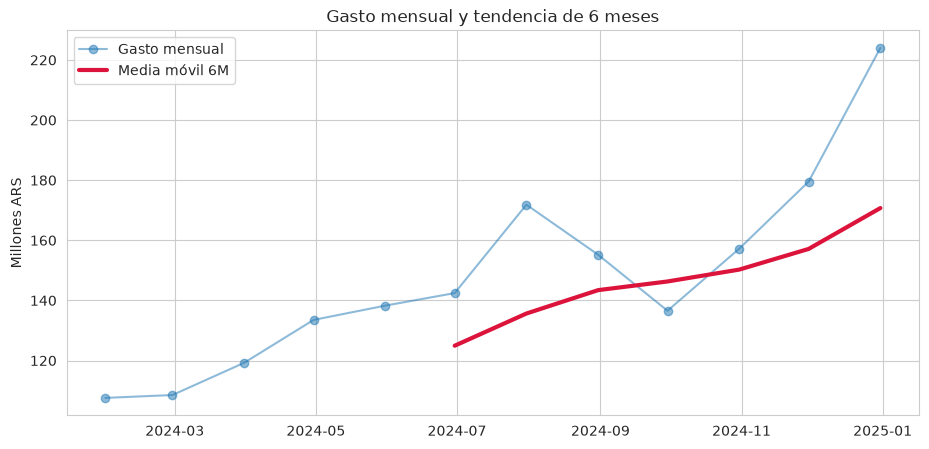

,mensual,mm6
fecha,,
2024-01-31,107.6,NaN
2024-02-29,108.5,NaN
2024-03-31,119.2,NaN
2024-04-30,133.5,NaN
2024-05-31,138.3,NaN
2024-06-30,142.4,124.9
2024-07-31,171.8,135.6
2024-08-31,155.2,143.4
2024-09-30,136.6,146.3


In [7]:
mensual = df.set_index('fecha').resample('ME')['monto_ars'].sum() / 1e6
mm6 = mensual.rolling(6).mean()

plt.plot(mensual.index, mensual.values, marker='o', alpha=0.5, label='Gasto mensual')
plt.plot(mm6.index, mm6.values, linewidth=3, color='crimson', label='Media móvil 6M')
plt.title('Gasto mensual y tendencia de 6 meses')
plt.ylabel('Millones ARS')
plt.legend()
plt.show()

pd.DataFrame({'mensual': mensual, 'mm6': mm6}).round(1)

**Lectura esperada:** el primer valor aparece en **junio** — hacen falta 6 meses para el primer promedio.
La media móvil de 6 meses **sube todos los meses**, incluidos agosto y septiembre: la caída de la serie cruda no llega a la tendencia.

### Ejercicio 7 · Participación por categoría

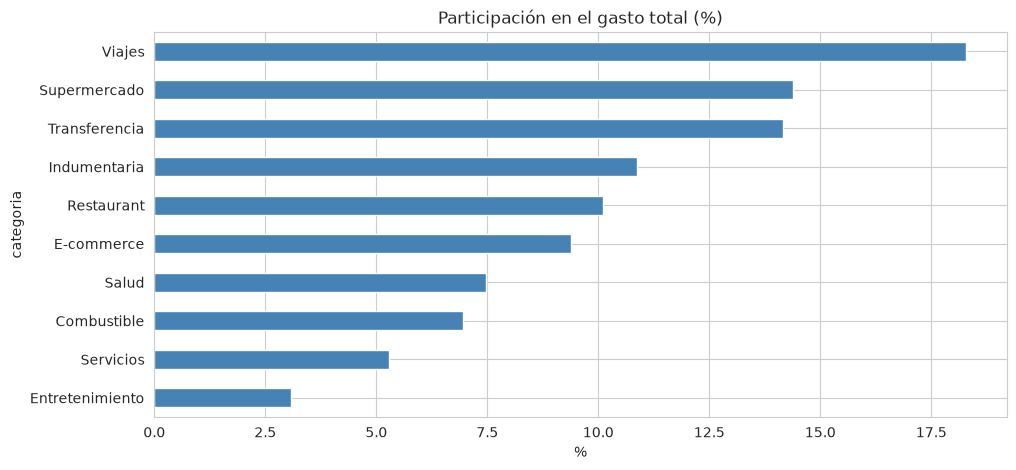

categoria
Viajes             18.3
Supermercado       14.4
Transferencia      14.2
Indumentaria       10.9
Restaurant         10.1
E-commerce          9.4
Salud               7.5
Combustible         7.0
Servicios           5.3
Entretenimiento     3.1
Name: monto_ars, dtype: float64
Top 3: 46.8%


In [8]:
share = (df.groupby('categoria')['monto_ars'].sum() / df['monto_ars'].sum() * 100).sort_values()

share.plot(kind='barh', color='steelblue')
plt.title('Participación en el gasto total (%)')
plt.xlabel('%')
plt.show()

print(share.sort_values(ascending=False).round(1))
print(f'Top 3: {share.sort_values(ascending=False).head(3).sum():.1f}%')

**Lectura esperada:** Viajes 18,3%, Supermercado 14,4%, Transferencia 14,2% → las tres primeras concentran **46,8%**.
Con diez categorías, la torta obliga a comparar ángulos parecidos; las barras ordenadas se leen de un vistazo.

### Ejercicio 8 · Estacionalidad de Viajes

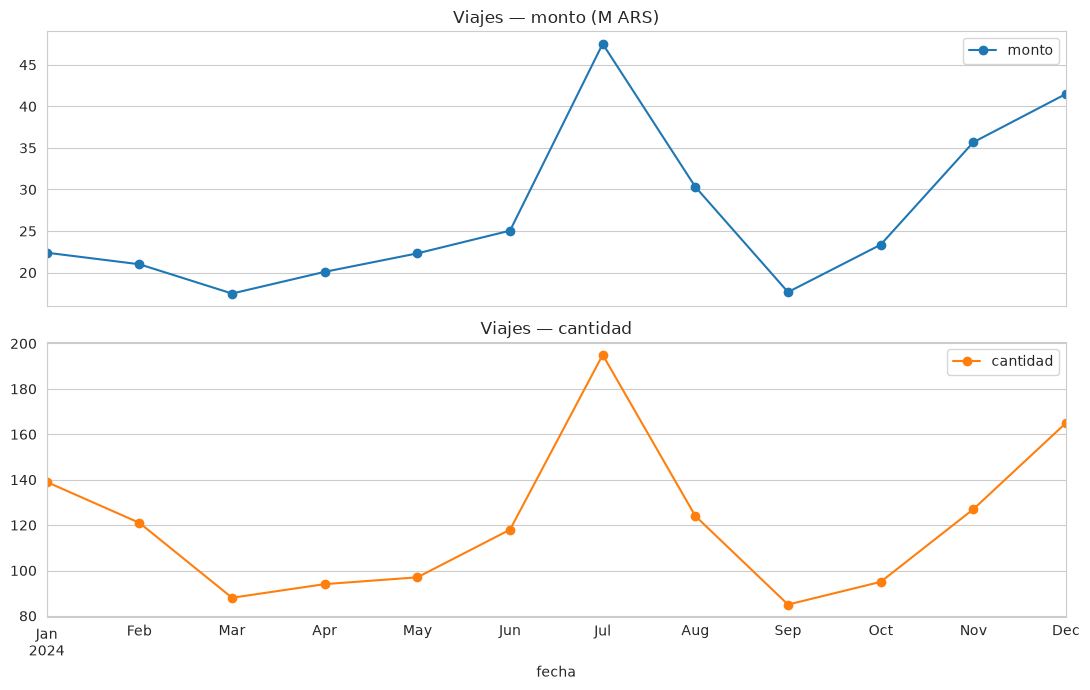

,monto,cantidad
fecha,,
2024-01-31,22.4,139
2024-02-29,21.0,121
2024-03-31,17.5,88
2024-04-30,20.1,94
2024-05-31,22.3,97
2024-06-30,25.0,118
2024-07-31,47.5,195
2024-08-31,30.3,124
2024-09-30,17.7,85


In [9]:
viajes = df[df['categoria'] == 'Viajes']
viajes_mes = viajes.set_index('fecha').resample('ME').agg(
    monto=('monto_ars', 'sum'),
    cantidad=('transaccion_id', 'count'),
)
viajes_mes['monto'] = viajes_mes['monto'] / 1e6

viajes_mes.plot(subplots=True, marker='o', figsize=(11, 7), title=['Viajes — monto (M ARS)', 'Viajes — cantidad'])
plt.tight_layout()
plt.show()

viajes_mes.round(1)

**Lectura esperada:** el pico claro es **julio** ($47,5M, 195 transacciones — vacaciones de invierno), y hay otra suba en **noviembre–diciembre**.
**Enero no aparece como pico en monto** ($22,4M, por debajo del promedio), aunque en cantidad es el tercer mes (139).
Ojo con el monto de diciembre: parte es inflación.

**La mejor respuesta:** "julio es claro; enero no se ve como esperaba; y con un solo año no puedo separar estacionalidad de un evento puntual".
Que alguien diga eso vale más que una respuesta forzada al calendario.

### Ejercicio 9 · Ticket por cliente por mes

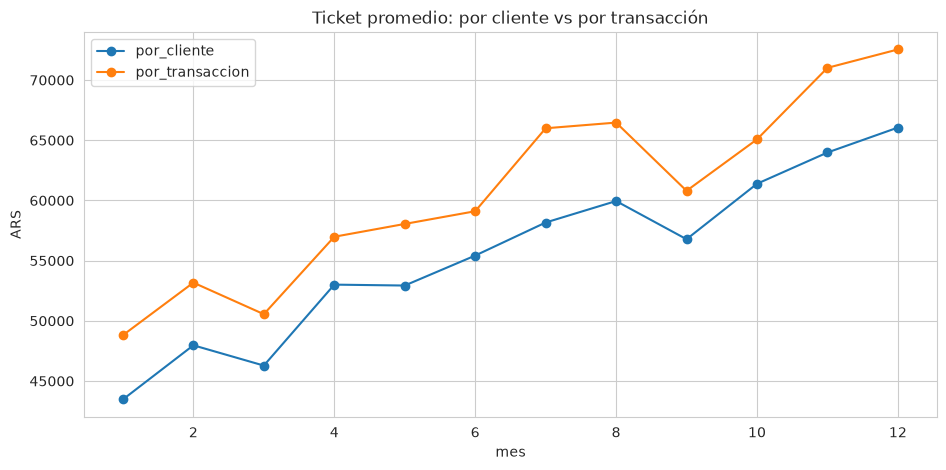

,por_cliente,por_transaccion
mes,,
1,43468.0,48807.0
2,47966.0,53171.0
3,46281.0,50550.0
4,53005.0,56982.0
5,52930.0,58046.0
6,55419.0,59102.0
7,58165.0,65993.0
8,59948.0,66465.0
9,56777.0,60799.0


In [10]:
por_cliente = df.groupby(['cliente_id', 'mes'])['monto_ars'].mean()
ticket_cliente = por_cliente.groupby('mes').mean()
ticket_transaccion = df.groupby('mes')['monto_ars'].mean()

comp = pd.DataFrame({'por_cliente': ticket_cliente, 'por_transaccion': ticket_transaccion}).round(0)
comp.plot(marker='o')
plt.title('Ticket promedio: por cliente vs por transacción')
plt.ylabel('ARS')
plt.show()
comp

**Lectura esperada:** el ticket "por cliente" es sistemáticamente menor (ene $43,5k vs $48,8k; dic $66,1k vs $72,5k).
En el promedio por transacción, los clientes que compran mucho y caro pesan más; en el promedio por cliente, cada cliente pesa igual.
Para "el cliente típico", la versión por cliente.

### Ejercicio 10 · Desafío — resumen trimestral

In [11]:
resumen_q = df.groupby('trimestre').agg(
    monto_total=('monto_ars', 'sum'),
    transacciones=('transaccion_id', 'count'),
    ticket_promedio=('monto_ars', 'mean'),
    clientes=('cliente_id', 'nunique'),
)

top_cat = (df.groupby(['trimestre', 'categoria'])['monto_ars'].sum()
             .reset_index()
             .sort_values('monto_ars', ascending=False)
             .groupby('trimestre').first()['categoria'])
resumen_q['categoria_top'] = top_cat
resumen_q['var_monto_%'] = (resumen_q['monto_total'].pct_change() * 100).round(1)
resumen_q['monto_total'] = (resumen_q['monto_total'] / 1e6).round(1)
resumen_q['ticket_promedio'] = resumen_q['ticket_promedio'].round(0)
resumen_q.index = ['Q1', 'Q2', 'Q3', 'Q4']
resumen_q

,monto_total,transacciones,ticket_promedio,clientes,categoria_top,var_monto_%
Q1,335.3,6604,50778.0,902,Viajes,NaN
Q2,414.2,7135,58053.0,879,Viajes,23.5
Q3,463.6,7185,64523.0,837,Viajes,11.9
Q4,560.7,8032,69814.0,785,Viajes,21.0


**Resultado:** monto $335M → $414M → $464M → $561M (+23,5%, +11,9%, +21,0%); transacciones 6.604 → 8.032 (+22%);
ticket $50,8k → $69,8k; **clientes 902 → 879 → 837 → 785 (−13%)**; Viajes es la categoría top en los cuatro trimestres.

**Bullets modelo:**
1. **Crecimiento:** el monto creció 67% en el año, pero las transacciones solo 22%: la mayor parte es precio
2. **Quién lo explica:** Viajes domina todos los trimestres; E-commerce es la que acelera (Q4 triplica a Q1)
3. **Alerta:** cada trimestre operan menos clientes (−13% en el año). El gasto se concentra en menos gente —
   el patrón que precede al churn que vimos en la Clase 2, tapado por ventas que se ven bien